# Crop type detection

In this notebook we will test Alpha Earth satellite embeddings.
We will firstly check France field ground truth with respect to EUROCROP and then to a model trained on AlphaEarth Embeddings

In [1]:
import geopandas as gpd
import ee
import os
import geemap
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.metrics import classification_report, confusion_matrix

In [3]:
# Some of main France RPG code, available from https://geoservices.ign.fr/sites/default/files/2021-07/DC_DL_RPG_2-0.pdf
GROUP_CODES = {
    1: "Soft wheat",
    2: "Grain maize and silage",
    3: "Barley",
    4: "Other cereals",
    5: "Rapeseed",
    6: "Sunflower",
    14: "Rice",
    16: "Fourrage"
}

CONTINUOUS_CLASSES = {
   "Soft wheat": 0,
   "Grain maize and silage": 1,
   "Barley": 2,
   "Other cereals": 3,
   "Rapeseed": 4,
   "Sunflower": 5,
   "Rice": 6,
   "Fourrage": 7,
   "others": 8
}

In [4]:
data_path = '../data/crop_type/RPG_2-0__SHP_LAMB93_R27_2022-01-01/RPG/1_DONNEES_LIVRAISON_2023-08-01/RPG_2-0_SHP_LAMB93_R27-2022/PARCELLES_GRAPHIQUES.shp'
dataset = gpd.read_file(data_path)

In [5]:
dataset.head()

,ID_PARCEL,SURF_PARC,CODE_CULTU,CODE_GROUP,CULTURE_D1,CULTURE_D2,geometry
0,30,8.93,SOJ,7,None,None,"POLYGON ((871751.463 6666592.595, 871754.109 6..."
1,37,1.43,MIS,2,None,None,"POLYGON ((878547.745 6666701.928, 878571.029 6..."
2,49,0.54,PPH,18,None,None,"POLYGON ((740829.917 6743137.428, 740834.547 6..."
3,61,7.50,PPH,18,None,None,"POLYGON ((792207.249 6574281.56, 792224.069 65..."
4,62,2.81,ORH,3,None,None,"POLYGON ((702973.582 6786877.066, 702973.582 6..."


In [6]:
dataset["CODE_GROUP"] = dataset["CODE_GROUP"].astype(int)
dataset["GROUP_NAME"] = dataset["CODE_GROUP"].map(GROUP_CODES).fillna("others")
dataset["CODE_GROUP_REMAPPED"] = dataset["GROUP_NAME"].map(CONTINUOUS_CLASSES)

# Find smallest class size
min_size = dataset["GROUP_NAME"].value_counts().min()

# Sample equally from each class
subset = (
    dataset.groupby("GROUP_NAME", group_keys=False)
      .apply(lambda x: x.sample(n=min_size, random_state=42))
)

#
test = subset.groupby("GROUP_NAME", group_keys=False).apply(
    lambda x: x.sample(frac=0.05, random_state=42)
)

C:\Users\degas\AppData\Local\Temp\ipykernel_7148\62475147.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min_size, random_state=42))
C:\Users\degas\AppData\Local\Temp\ipykernel_7148\62475147.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  test = subset.groupby("GROUP_NAME", group_keys=False).apply(


In [7]:
test.shape

(4176, 9)

In [8]:
test["GROUP_NAME"].value_counts()

GROUP_NAME
Barley                    522
Fourrage                  522
Grain maize and silage    522
Other cereals             522
Rapeseed                  522
Soft wheat                522
Sunflower                 522
others                    522
Name: count, dtype: int64

In [9]:
test["CODE_GROUP_REMAPPED"].value_counts()

CODE_GROUP_REMAPPED
2    522
7    522
1    522
3    522
4    522
0    522
5    522
8    522
Name: count, dtype: int64

In [10]:
test.crs

<Projected CRS: IGNF:LAMB93>
Name: RGF93 Lambert 93
Axis Info [cartesian]:
- [east]: Easting (metre)
- [north]: Northing (metre)
Area of Use:
- undefined
Coordinate Operation:
- name: unnamed
- method: Lambert Conic Conformal (2SP)
Datum: Reseau Geodesique Francais 1993 v1
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [11]:
# same as EUROCROP layer
test = test.to_crs("EPSG:3035")

In [12]:
test.shape

(4176, 9)

In [13]:
# let's store the data as asset on google earth engine this will reduce transferred data in this notebook
os.makedirs('../data/assets/', exist_ok=True)
file_path = '../data/assets/test_data_2022.shp'
test = test.rename(columns={
    "CODE_GROUP_REMAPPED": "CLASS_ID"
})
test["CLASS_ID"] = test["CLASS_ID"].astype(int)
test.to_file(file_path)

In [14]:
test["CLASS_ID"].value_counts()

CLASS_ID
2    522
7    522
1    522
3    522
4    522
0    522
5    522
8    522
Name: count, dtype: int64

In [15]:
# file downloaded from https://simplemaps.com/gis/country/fr
regions = gpd.read_file("../data/fr_shp/fr.shp")
regions = regions.to_crs(subset.crs)

In [16]:
regions.head()

,id,name,source,geometry
0,FRHDF,Hauts de France,https://simplemaps.com,"POLYGON ((787334.124 6984652.016, 787513.726 6..."
1,FRGES,Grand Est,https://simplemaps.com,"POLYGON ((735069.836 6861223.452, 736114.489 6..."
2,FRPAC,Provence Alpes CÃ´te d'Azu,https://simplemaps.com,"MULTIPOLYGON (((797633.69 6263057.523, 799668...."
3,FRARA,Auvergne RhÃ´ne Alpes,https://simplemaps.com,"POLYGON ((985262.138 6453697.249, 985165.368 6..."
4,FRBFC,Bourgogne Franche ComtÃ©,https://simplemaps.com,"POLYGON ((729257.704 6812457.121, 730559.223 6..."


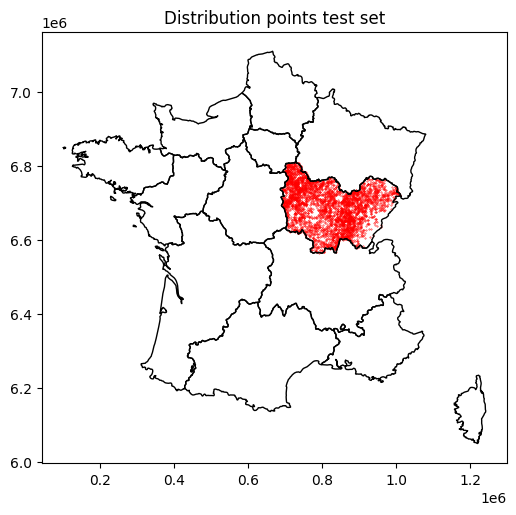

In [17]:
# Plot
fig, ax = plt.subplots(figsize=(6,6))

regions.boundary.plot(ax=ax, linewidth=1, edgecolor="black")
subset_centroids = test.geometry.centroid
subset_centroids = test.copy()
subset_centroids["geometry"] = subset.geometry.centroid
subset_centroids.plot(
    ax=ax,
    color="red",
    markersize=0.1    # increase size here
)

plt.title("Distribution points test set")
plt.show()

In [18]:
# now that we have prepared the dataset we can check how existing layers performs in crop type detection
# later we will see how embeddings can be sued for similar purposes

In [19]:
# connection to GEE
ee.Authenticate()
ee.Initialize(project="alphaearth-476700")


Successfully saved authorization token.


In [20]:
# Eurocrop
cropmap = ee.ImageCollection("JRC/D5/EUCROPMAP/V1") \
             .filterDate('2022-01-01', '2022-12-31') \
             .first()

cropmap = cropmap.select("classification")

In [21]:
crs = cropmap.projection().crs().getInfo()
print(crs)

EPSG:3035


In [22]:
# fc = geemap.geopandas_to_ee(test)
asset_id = 'projects/alphaearth-476700/assets/test_data_2022'
fc = ee.FeatureCollection(asset_id)

samples = cropmap.reduceRegions(
    collection=fc,
    reducer=ee.Reducer.mode(),   # modal class inside polygon
    scale=30
)
test_gdf = geemap.ee_to_gdf(samples)

In [23]:
# source: https://developers.google.com/earth-engine/datasets/catalog/JRC_D5_EUCROPMAP_V1
EUCROPMAP_CLASSES = {
    100: "Artificial",
    211: "Common wheat",
    212: "Durum wheat",
    213: "Barley",
    214: "Rye",
    215: "Oats",
    216: "Maize",
    217: "Rice",
    218: "Triticale",
    219: "Other cereals",
    221: "Potatoes",
    222: "Sugar beet",
    223: "Other root crops",
    230: "Other non-permanent industrial crops",
    231: "Sunflower",
    232: "Rapeseed & turnip rapeseed",
    233: "Soya",
    240: "Dry pulses",
    250: "Fodder crops (cereals + leguminous)",
    290: "Bare arable land",
    300: "Woodland & shrubland (incl. permanent crops)",
    500: "Grasslands",
    600: "Bare land / lichens & moss",
    700: "Water",
    800: "Wetlands"
}


In [24]:
test_gdf["EUCROP_TYPE"] = (
    test_gdf["mode"]
    .astype(float)      # GEE often returns floats like 241.0
    .astype(int)        # convert to int keys
    .map(EUCROPMAP_CLASSES)
    .fillna("others")   # for unmapped classes
)

In [25]:
# Harmonize to the used RPG classes

EUCROP_TO_RPG = {
    211: 1,   # Common wheat → Soft wheat
    212: 1,   # Durum wheat → Soft wheat  (close enough category)
    216: 2,   # Maize → Grain maize & silage
    # EUCROPMAP does not distinguish grain vs silage
    213: 3,   # Barley → Barley
    214: 4,   # Rye → Other cereals
    215: 4,   # Oats → Other cereals
    218: 4,   # Triticale → Other cereals
    219: 4,   # Other cereals → Other cereals
    232: 5,   # Rapeseed & turnip rapeseed → Rapeseed
    231: 6,   # Sunflower → Sunflower
    217: 14,  # Rice → Rice
    250: 16,  # Fodder crops (cereals + legumes) → Fourrage
}

In [26]:
test_gdf["RPG_GROUP_PREDICTION"] = (
    test_gdf["mode"]
    .astype(float)
    .astype(int)
    .map(EUCROP_TO_RPG)
    .fillna("others")
)

In [27]:
test_gdf["RPG_NAME_PREDICTION"] = (
    test_gdf["RPG_GROUP_PREDICTION"]
    .map(GROUP_CODES)
    .fillna("others")
)

In [28]:
np.unique(test_gdf["EUCROP_TYPE"].values)

array(['Artificial', 'Bare arable land', 'Barley', 'Common wheat',
       'Dry pulses', 'Durum wheat', 'Fodder crops (cereals + leguminous)',
       'Grasslands', 'Maize', 'Oats', 'Other cereals',
       'Other non-permanent industrial crops', 'Potatoes',
       'Rapeseed & turnip rapeseed', 'Rye', 'Soya', 'Sugar beet',
       'Sunflower', 'Triticale',
       'Woodland & shrubland (incl. permanent crops)', 'others'],
      dtype=object)

In [29]:
np.unique(test_gdf["RPG_NAME_PREDICTION"].values)

array(['Barley', 'Fourrage', 'Grain maize and silage', 'Other cereals',
       'Rapeseed', 'Soft wheat', 'Sunflower', 'others'], dtype=object)

In [30]:
samples_subset = test_gdf

In [31]:
np.unique(samples_subset["GROUP_NAME"].values)

array(['Barley', 'Fourrage', 'Grain maize and silage', 'Other cereals',
       'Rapeseed', 'Soft wheat', 'Sunflower', 'others'], dtype=object)

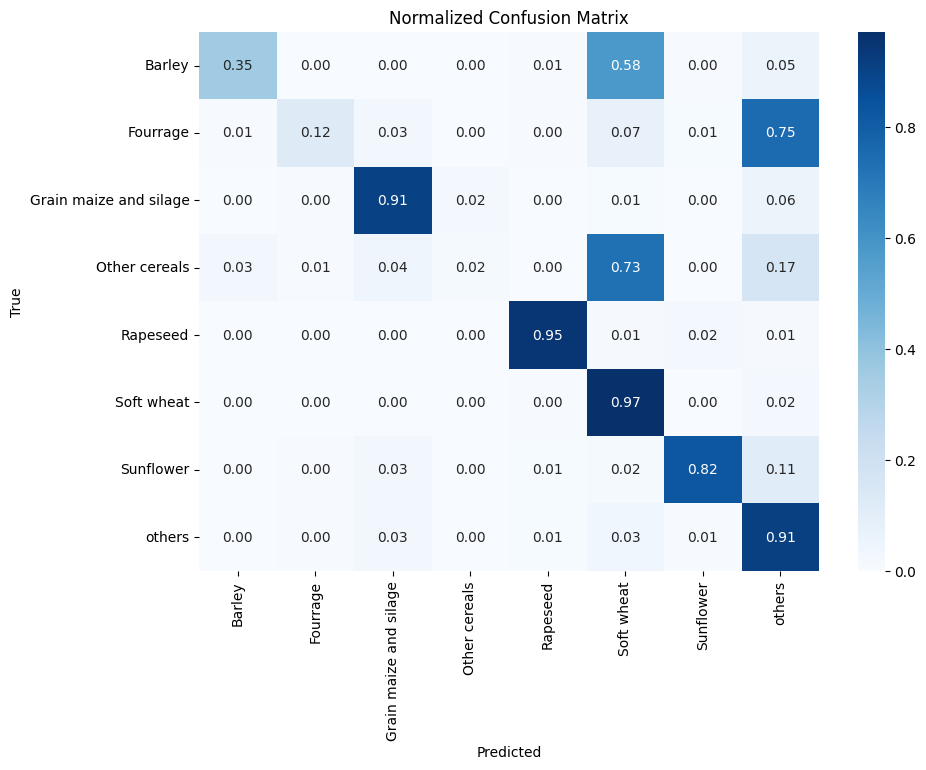

In [32]:
labels = sorted(samples_subset["GROUP_NAME"].unique())

cm = confusion_matrix(
    samples_subset["GROUP_NAME"],
    samples_subset["RPG_NAME_PREDICTION"],
    labels=labels,
    normalize="true"   # <-- normalize rows (true labels)
)

plt.figure(figsize=(10, 7))
sns.heatmap(
    cm, annot=True, fmt=".2f", cmap="Blues",
    xticklabels=labels, yticklabels=labels
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Normalized Confusion Matrix")
plt.show()

In [33]:
print(classification_report(samples_subset["GROUP_NAME"],
                            samples_subset["RPG_NAME_PREDICTION"]))

                        precision    recall  f1-score   support

                Barley       0.89      0.35      0.51       522
              Fourrage       0.86      0.12      0.21       522
Grain maize and silage       0.87      0.91      0.89       522
         Other cereals       0.41      0.02      0.03       522
              Rapeseed       0.97      0.95      0.96       522
            Soft wheat       0.40      0.97      0.57       522
             Sunflower       0.95      0.82      0.88       522
                others       0.44      0.91      0.59       522

              accuracy                           0.63      4176
             macro avg       0.72      0.63      0.58      4176
          weighted avg       0.72      0.63      0.58      4176



# Classification with AlphaEarth embeddings

We will train a simple ML model on the nearby region to the test set used in the previous example and then do inference on the test set

In [34]:
train_val_data_path = '../data/crop_type/RPG_2-0__SHP_LAMB93_R84_2022-01-01/RPG/1_DONNEES_LIVRAISON_2023-08-01/RPG_2-0_SHP_LAMB93_R84-2022/PARCELLES_GRAPHIQUES.shp'

In [35]:
train_val_dataset = gpd.read_file(train_val_data_path)

In [36]:
train_val_dataset.head()

,ID_PARCEL,SURF_PARC,CODE_CULTU,CODE_GROUP,CULTURE_D1,CULTURE_D2,geometry
0,1,2.12,PPH,18,None,None,"POLYGON ((921775.498 6457548.115, 921793.945 6..."
1,21,2.48,MIS,2,None,None,"POLYGON ((877307.011 6575997.177, 877293.386 6..."
2,26,0.47,SNE,28,None,None,"POLYGON ((863345.088 6360418.838, 863360.991 6..."
3,32,14.61,SPH,17,None,None,"POLYGON ((928810.39 6582615.624, 928740.102 65..."
4,40,3.12,PPH,18,None,None,"POLYGON ((923183.08 6544961.15, 923159.88 6544..."


In [37]:
train_val_dataset["CODE_GROUP"] = train_val_dataset["CODE_GROUP"].astype(int)
train_val_dataset["GROUP_NAME"] = train_val_dataset["CODE_GROUP"].map(GROUP_CODES).fillna("others")

In [38]:
train_val_dataset["CODE_GROUP_REMAPPED"] = train_val_dataset["GROUP_NAME"].map(CONTINUOUS_CLASSES)

In [39]:
np.unique(train_val_dataset["GROUP_NAME"].values)

array(['Barley', 'Fourrage', 'Grain maize and silage', 'Other cereals',
       'Rapeseed', 'Rice', 'Soft wheat', 'Sunflower', 'others'],
      dtype=object)

In [40]:
np.unique(train_val_dataset["CODE_GROUP"].values)

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 11, 14, 15, 16, 17, 18, 19, 20,
       21, 22, 23, 24, 25, 28])

In [41]:
np.unique(train_val_dataset["CODE_GROUP_REMAPPED"].values)

array([0, 1, 2, 3, 4, 5, 6, 7, 8])

In [42]:
train_val_dataset["GROUP_NAME"].value_counts()

GROUP_NAME
others                    1066931
Soft wheat                  70433
Grain maize and silage      66705
Other cereals               56967
Fourrage                    54205
Barley                      28229
Sunflower                   13185
Rapeseed                     9867
Rice                            2
Name: count, dtype: int64

In [43]:
train_val_dataset["CODE_GROUP_REMAPPED"].value_counts()

CODE_GROUP_REMAPPED
8    1066931
0      70433
1      66705
3      56967
7      54205
2      28229
5      13185
4       9867
6          2
Name: count, dtype: int64

In [44]:
# skip rice, it is not typical European crop
train_val_dataset = train_val_dataset[train_val_dataset["GROUP_NAME"] != "Rice"]

In [45]:
# Find smallest class size
min_size = train_val_dataset["GROUP_NAME"].value_counts().min()

# Sample equally from each class
subset = (
    train_val_dataset.groupby("GROUP_NAME", group_keys=False)
      .apply(lambda x: x.sample(n=min_size, random_state=42))
)

# 
subset_train_val = subset.groupby("GROUP_NAME", group_keys=False).apply(
    lambda x: x.sample(frac=0.2, random_state=42)
)

C:\Users\degas\AppData\Local\Temp\ipykernel_7148\543888332.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min_size, random_state=42))
C:\Users\degas\AppData\Local\Temp\ipykernel_7148\543888332.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  subset_train_val = subset.groupby("GROUP_NAME", group_keys=False).apply(


In [46]:
subset_train_val.shape

(15784, 9)

In [47]:
np.unique(subset_train_val["CODE_GROUP_REMAPPED"].values)

array([0, 1, 2, 3, 4, 5, 7, 8])

In [48]:
subset_train_val = subset_train_val.to_crs("EPSG:4326")

In [49]:
regions = regions.to_crs(subset_train_val.crs)

C:\Users\degas\AppData\Local\Temp\ipykernel_7148\1600409782.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  subset_centroids = subset_train_val.geometry.centroid
C:\Users\degas\AppData\Local\Temp\ipykernel_7148\1600409782.py:7: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  subset_centroids["geometry"] = subset_train_val.geometry.centroid


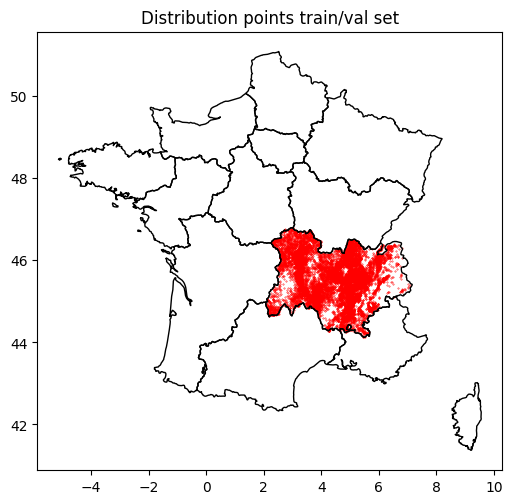

In [50]:
# Plot
fig, ax = plt.subplots(figsize=(6,6))

regions.boundary.plot(ax=ax, linewidth=1, edgecolor="black")
subset_centroids = subset_train_val.geometry.centroid
subset_centroids = subset_train_val.copy()
subset_centroids["geometry"] = subset_train_val.geometry.centroid
subset_centroids.plot(
    ax=ax,
    color="red",
    markersize=0.1    # increase size here
)

plt.title("Distribution points train/val set")
plt.show()

In [51]:
# quick check before saving

subset_train_val["CODE_GROUP_REMAPPED"].value_counts()

CODE_GROUP_REMAPPED
2    1973
7    1973
1    1973
3    1973
4    1973
0    1973
5    1973
8    1973
Name: count, dtype: int64

In [52]:
subset_train_val.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [53]:
os.makedirs('../data/assets/', exist_ok=True)
file_path = '../data/assets/training_data_2022.shp'
subset_train_val = subset_train_val.rename(columns={
    "CODE_GROUP_REMAPPED": "CLASS_ID"
})
subset_train_val["CLASS_ID"] = subset_train_val["CLASS_ID"].astype(int)
subset_train_val.to_file(file_path)

In [54]:
# NOTE: asset ID should not include the extension
asset_id = 'projects/alphaearth-476700/assets/training_data_2022'
fc = ee.FeatureCollection(asset_id)

In [55]:
emb = ee.ImageCollection('GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL') \
    .filterDate('2022-01-01', '2023-01-01') \
    .mosaic()

# Compute mean embeddings per parcel directly
def add_emb(f):
    vec = emb.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=f.geometry(),
        scale=10,
        maxPixels=1e13
    )
    return f.set(vec)

# fc = geemap.gdf_to_ee(subset_train_val)
fc_with_emb = fc.map(add_emb)

In [56]:
columns = fc.first().propertyNames().getInfo()

In [57]:
columns

['CODE_CULTU',
 'GROUP_NAME',
 'CULTURE_D1',
 'CULTURE_D2',
 'ID_PARCEL',
 'SURF_PARC',
 'CODE_GROUP',
 'CLASS_ID',
 'system:index']

In [58]:
# let's select only a subset

In [59]:
embedding_bands = [f"A{i:02d}" for i in range(64)]

In [60]:
# feature for train and val
# CODE_GROUP_REMAPPED is truncated to 10 chars .e. CODE_GROUP_R
features = fc_with_emb.select(embedding_bands + ['CLASS_ID'])

In [61]:
# Random split
training_fc = features.randomColumn('rand', seed=42)
train_fc = training_fc.filter('rand < 0.8')
val_fc   = training_fc.filter('rand >= 0.8')

In [101]:
# Train RF classifier
# NOTE: the best would have been to use the validation in training to avoid overfitting however it looks GEE smileRandomForest doesn't support that natively in the training
# https://developers.google.com/earth-engine/apidocs/ee-classifier-smilerandomforest
# UPDATE: SVM looks to work better (see next cell)
#classifier = ee.Classifier.smileRandomForest(200).train(
#    features=train_fc,
#    classProperty='CLASS_ID',
#    inputProperties=embedding_bands
#)

In [ ]:
# Create and train a linear SVM classifier
classifier = ee.Classifier.libsvm(
    kernelType='LINEAR',  # Linear kernel
    cost=1                # Regularization parameter (C)
).train(
    features=train_fc,    
    classProperty='CLASS_ID',  
    inputProperties=embedding_bands 
)


In [64]:
print("Val size")
val_fc.size().getInfo() 

Val size


3241

In [65]:
# Validate separatly
val_classified = val_fc.classify(classifier)
conf_matrix = val_classified.errorMatrix('CLASS_ID', 'classification')

In [66]:
# takes long time (2-3 minutes) the best would be to export to drive and then download
cm = conf_matrix.getInfo()

In [67]:
cm_df = pd.DataFrame(cm)

In [68]:
valid_ids = list(CONTINUOUS_CLASSES.values())

# Keep only rows & columns that match these labels
filtered_df = cm_df.loc[valid_ids, valid_ids]

In [69]:
# the value should amtch the val size, it is worth to check ebcause sometimes some rpedictions are nan
np.sum(np.sum(filtered_df))

c:\Users\degas\Documents\Github\Geospatial-embeddings-use-cases\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


np.int64(3241)

In [70]:
inv_mapping = {v: k for k, v in CONTINUOUS_CLASSES.items()}

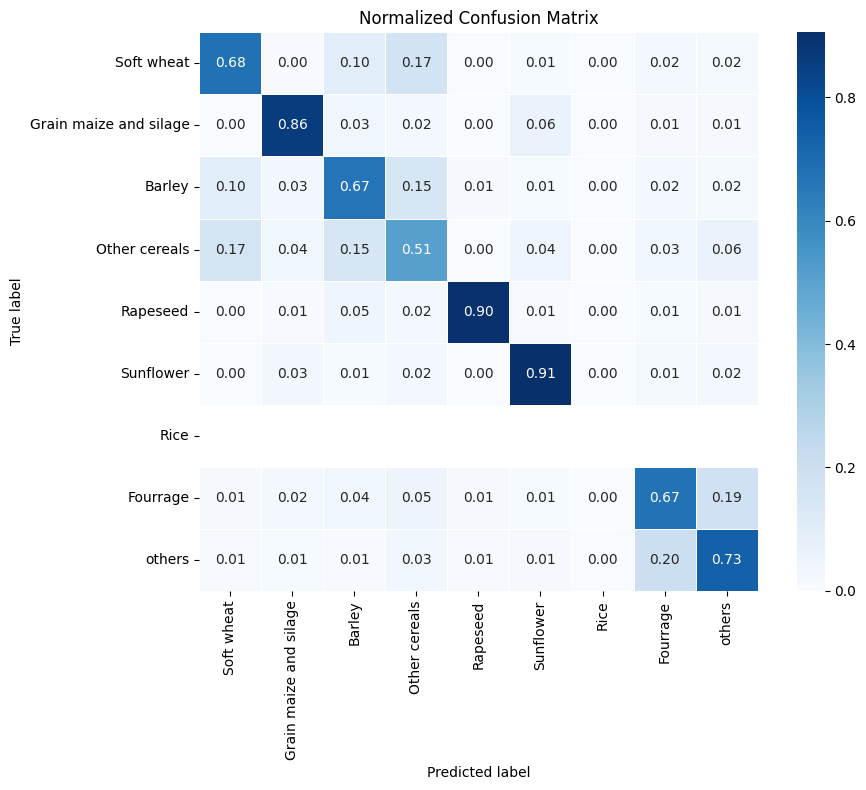

In [71]:
df_named = filtered_df.rename(index=inv_mapping, columns=inv_mapping)
cm_norm = df_named.div(df_named.sum(axis=1), axis=0)


plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    linewidths=.5,
    square=True
)

plt.title("Normalized Confusion Matrix")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()

In [73]:
y_true = []
y_pred = []

for true_label in df_named.index.tolist(): # Iterates through all classes
    # Check if this class has any true samples (row sum > 0)
    if df_named.loc[true_label].sum() > 0:
        for pred_label in df_named.columns.tolist():
            count = df_named.loc[true_label, pred_label]
            if count > 0:
                y_true.extend([true_label] * count)
                y_pred.extend([pred_label] * count)

# Extract the actual labels present in the ground truth
# This prevents passing an empty class label to the report function.
actual_labels_in_data = sorted(list(set(y_true)))

# Generate the report using only the labels present
report = classification_report(
    y_true, 
    y_pred, 
    labels=actual_labels_in_data, 
    zero_division=0 # Ensure this is set to 0 or 'warn'
)  
print(report)

                        precision    recall  f1-score   support

                Barley       0.63      0.67      0.65       390
              Fourrage       0.69      0.67      0.68       415
Grain maize and silage       0.87      0.86      0.86       395
         Other cereals       0.52      0.51      0.51       405
              Rapeseed       0.96      0.90      0.93       393
            Soft wheat       0.71      0.68      0.69       420
             Sunflower       0.87      0.91      0.89       423
                others       0.69      0.73      0.71       400

              accuracy                           0.74      3241
             macro avg       0.74      0.74      0.74      3241
          weighted avg       0.74      0.74      0.74      3241



# Prediction on the test set (nearby region same year)

In [74]:
test = test.to_crs(regions.crs)

C:\Users\degas\AppData\Local\Temp\ipykernel_7148\1095885932.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  subset_centroids = test.geometry.centroid
C:\Users\degas\AppData\Local\Temp\ipykernel_7148\1095885932.py:7: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  subset_centroids["geometry"] = test.geometry.centroid


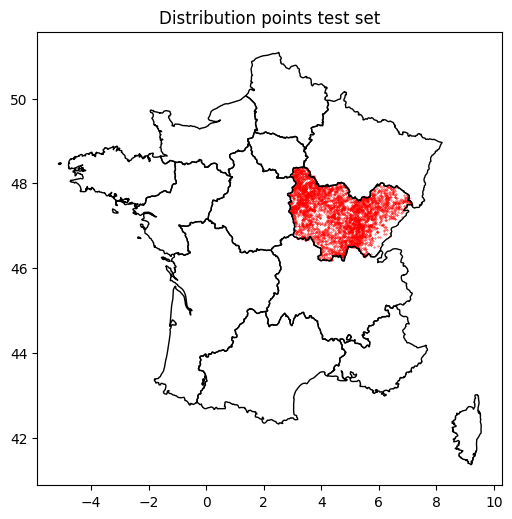

In [75]:
# Plot
fig, ax = plt.subplots(figsize=(6,6))

regions.boundary.plot(ax=ax, linewidth=1, edgecolor="black")
subset_centroids = test.geometry.centroid
subset_centroids = test.copy()
subset_centroids["geometry"] = test.geometry.centroid
subset_centroids.plot(
    ax=ax,
    color="red",
    markersize=0.1    # increase size here
)

plt.title("Distribution points test set")
plt.show()

In [76]:
asset_id = 'projects/alphaearth-476700/assets/test_data_2022'
fc = ee.FeatureCollection(asset_id)

In [77]:
emb = ee.ImageCollection('GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL') \
    .filterDate('2022-01-01', '2023-01-01') \
    .mosaic()

# Compute mean embeddings per parcel directly
def add_emb(f):
    vec = emb.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=f.geometry(),
        scale=10,
        maxPixels=1e13
    )
    return f.set(vec)

# fc = geemap.gdf_to_ee(subset_train_val)
fc_with_emb = fc.map(add_emb)

In [78]:
# feature for train and val
test_features = fc_with_emb.select(embedding_bands + ['CLASS_ID'])

In [79]:
count = test_features.size().getInfo()
print(count)

4176


In [80]:
# not used
def classify_in_batches(fc, classifier, batch_size=500):
    """
    Classify a large FeatureCollection in batches to avoid
    payload and computation limits.
    """
    # Convert to list ONCE on the server
    fc_list = fc.toList(fc.size())
    
    # Number of features (client-side integer)
    n = fc.size().getInfo() 
    
    results = []
    
    for start in range(0, n, batch_size):
        print(f"Batch {start}")
        end = min(start + batch_size, n)
        
        # Server-side slicing: from start to end
        batch_list = fc_list.slice(start, end)
        batch_fc = ee.FeatureCollection(batch_list)
        
        # Classify the batch
        batch_classified = batch_fc.classify(classifier)
        results.append(batch_classified)
        
    # Merge all classified batches back together
    merged = ee.FeatureCollection(results).flatten()
    return merged

In [81]:
# Test
test_classified = test_features.classify(classifier)
conf_matrix = test_classified.errorMatrix('CLASS_ID', 'classification')

In [82]:
cm = conf_matrix.getInfo()
cm_df = pd.DataFrame(cm)

In [83]:
np.sum(np.sum(cm_df))

c:\Users\degas\Documents\Github\Geospatial-embeddings-use-cases\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


np.int64(4176)

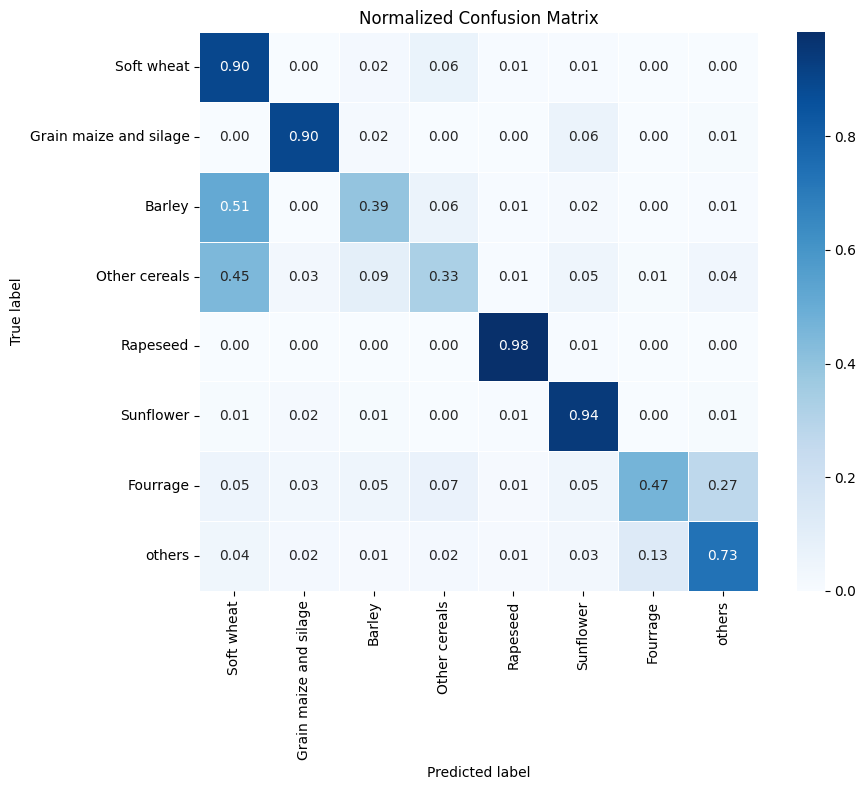

In [84]:
df_named = cm_df.rename(index=inv_mapping, columns=inv_mapping)
df_named = df_named.drop(index='Rice', columns='Rice')
cm_norm = df_named.div(df_named.sum(axis=1), axis=0)


plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    linewidths=.5,
    square=True
)

plt.title("Normalized Confusion Matrix")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()

In [85]:
np.sum(np.sum(df_named))

c:\Users\degas\Documents\Github\Geospatial-embeddings-use-cases\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


np.int64(4176)

In [86]:
# cm is your confusion matrix as a DataFrame
labels = df_named.index.tolist()  # ['Soft wheat', 'Grain maize and silage', ..., 'others']

# True labels: repeat each row index according to row sums
y_true = np.repeat(labels, df_named.sum(axis=1).values)

# Predicted labels: flatten each row according to counts
y_pred = []
for true_label in labels:
    counts = df_named.loc[true_label].values
    y_pred.extend(np.repeat(labels, counts))  # labels are columns
y_pred = np.array(y_pred)

report = classification_report(y_true, y_pred, labels=labels, digits=3)
print(report)


                        precision    recall  f1-score   support

            Soft wheat      0.456     0.897     0.605       522
Grain maize and silage      0.897     0.897     0.897       522
                Barley      0.653     0.393     0.490       522
         Other cereals      0.594     0.328     0.422       522
              Rapeseed      0.948     0.983     0.965       522
             Sunflower      0.814     0.941     0.873       522
              Fourrage      0.760     0.467     0.579       522
                others      0.679     0.730     0.704       522

              accuracy                          0.704      4176
             macro avg      0.725     0.704     0.692      4176
          weighted avg      0.725     0.704     0.692      4176



# Let's print again EUROCROP results and compare

In [87]:
print(classification_report(samples_subset["GROUP_NAME"],
                            samples_subset["RPG_NAME_PREDICTION"]))

                        precision    recall  f1-score   support

                Barley       0.89      0.35      0.51       522
              Fourrage       0.86      0.12      0.21       522
Grain maize and silage       0.87      0.91      0.89       522
         Other cereals       0.41      0.02      0.03       522
              Rapeseed       0.97      0.95      0.96       522
            Soft wheat       0.40      0.97      0.57       522
             Sunflower       0.95      0.82      0.88       522
                others       0.44      0.91      0.59       522

              accuracy                           0.63      4176
             macro avg       0.72      0.63      0.58      4176
          weighted avg       0.72      0.63      0.58      4176



# Prediction year+1 (training region)

In [88]:
data_path = '../data/crop_type/RPG_2-2__SHP_LAMB93_R27_2023-01-01/RPG/1_DONNEES_LIVRAISON_2023/RPG_2-2__SHP_LAMB93_R27_2023-01-01/PARCELLES_GRAPHIQUES.shp'
dataset = gpd.read_file(data_path)

In [89]:
dataset["CODE_GROUP"] = dataset["CODE_GROUP"].astype(int)
dataset["GROUP_NAME"] = dataset["CODE_GROUP"].map(GROUP_CODES).fillna("others")
dataset["CODE_GROUP_REMAPPED"] = dataset["GROUP_NAME"].map(CONTINUOUS_CLASSES)

# Find smallest class size
min_size = dataset["GROUP_NAME"].value_counts().min()

# Sample equally from each class
subset = (
    dataset.groupby("GROUP_NAME", group_keys=False)
      .apply(lambda x: x.sample(n=min_size, random_state=42))
)

#
test_n = subset.groupby("GROUP_NAME", group_keys=False).apply(
    lambda x: x.sample(frac=0.05, random_state=42)
)

C:\Users\degas\AppData\Local\Temp\ipykernel_7148\1047224065.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min_size, random_state=42))
C:\Users\degas\AppData\Local\Temp\ipykernel_7148\1047224065.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  test_n = subset.groupby("GROUP_NAME", group_keys=False).apply(


In [90]:
test_n["CODE_GROUP_REMAPPED"].value_counts()

CODE_GROUP_REMAPPED
2    524
7    524
1    524
3    524
4    524
0    524
5    524
8    524
Name: count, dtype: int64

In [91]:
# let's store the data as asset on google earth engine this will reduce transferred data in this notebook
os.makedirs('../data/assets/', exist_ok=True)
file_path = '../data/assets/test_data_2023.shp'
test_n = test_n.rename(columns={
    "CODE_GROUP_REMAPPED": "CLASS_ID"
})
test_n["CLASS_ID"] = test_n["CLASS_ID"].astype(int)
test_n.to_file(file_path)

C:\Users\degas\AppData\Local\Temp\ipykernel_7148\3483304823.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  subset_centroids = test_n.geometry.centroid
C:\Users\degas\AppData\Local\Temp\ipykernel_7148\3483304823.py:8: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  subset_centroids["geometry"] = test_n.geometry.centroid


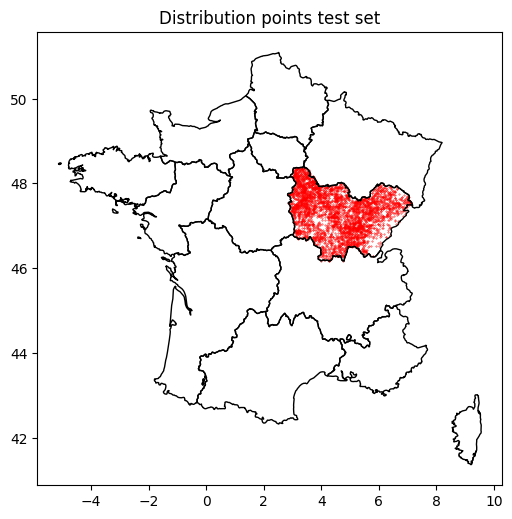

In [92]:
# Plot
fig, ax = plt.subplots(figsize=(6,6))

regions.boundary.plot(ax=ax, linewidth=1, edgecolor="black")
test_n = test_n.to_crs(regions.crs)
subset_centroids = test_n.geometry.centroid
subset_centroids = test_n.copy()
subset_centroids["geometry"] = test_n.geometry.centroid
subset_centroids.plot(
    ax=ax,
    color="red",
    markersize=0.1    # increase size here
)

plt.title("Distribution points test set")
plt.show()

In [93]:
# fc = geemap.geopandas_to_ee(test)
asset_id = 'projects/alphaearth-476700/assets/test_data_2023'
fc = ee.FeatureCollection(asset_id)

In [94]:
emb = ee.ImageCollection('GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL') \
    .filterDate('2023-01-01', '2024-01-01') \
    .mosaic()

# Compute mean embeddings per parcel directly
def add_emb(f):
    vec = emb.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=f.geometry(),
        scale=10,
        maxPixels=1e13
    )
    return f.set(vec)

# fc = geemap.gdf_to_ee(subset_train_val)
fc_with_emb = fc.map(add_emb)

In [95]:
test_features = fc_with_emb.select(embedding_bands + ['CLASS_ID'])

In [96]:
# Validate separatly
test_n_classified = test_features.classify(classifier)
conf_matrix = test_n_classified.errorMatrix('CLASS_ID', 'classification')

In [97]:
cm = conf_matrix.getInfo()
cm_df = pd.DataFrame(cm)

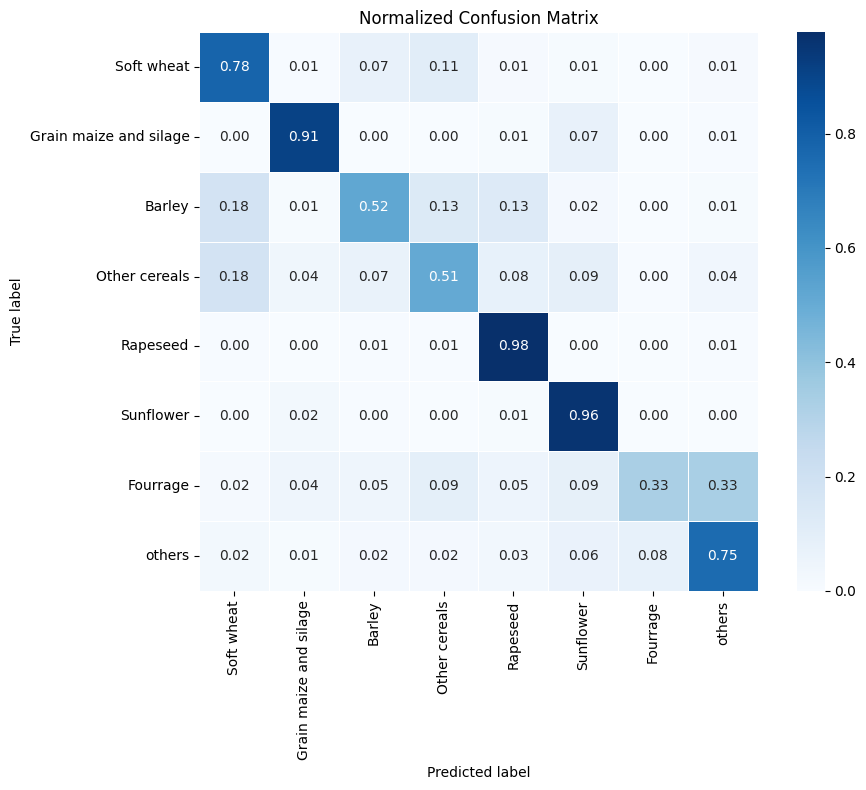

In [98]:
df_named = cm_df.rename(index=inv_mapping, columns=inv_mapping)
df_named = df_named.drop(index='Rice', columns='Rice')
cm_norm = df_named.div(df_named.sum(axis=1), axis=0)


plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    linewidths=.5,
    square=True
)

plt.title("Normalized Confusion Matrix")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()

In [99]:
# cm is your confusion matrix as a DataFrame
labels = df_named.index.tolist()  # ['Soft wheat', 'Grain maize and silage', ..., 'others']

# True labels: repeat each row index according to row sums
y_true = np.repeat(labels, df_named.sum(axis=1).values)

# Predicted labels: flatten each row according to counts
y_pred = []
for true_label in labels:
    counts = df_named.loc[true_label].values
    y_pred.extend(np.repeat(labels, counts))  # labels are columns
y_pred = np.array(y_pred)

report = classification_report(y_true, y_pred, labels=labels, digits=3)
print(report)

                        precision    recall  f1-score   support

            Soft wheat      0.659     0.781     0.714       524
Grain maize and silage      0.875     0.908     0.891       524
                Barley      0.702     0.521     0.598       524
         Other cereals      0.585     0.508     0.543       524
              Rapeseed      0.756     0.977     0.853       524
             Sunflower      0.735     0.960     0.833       524
              Fourrage      0.797     0.330     0.467       524
                others      0.651     0.752     0.698       524

              accuracy                          0.717      4192
             macro avg      0.720     0.717     0.700      4192
          weighted avg      0.720     0.717     0.700      4192



In [100]:
# the model trained on 2022 data, seems to be able to predict also for next year